In [114]:
#import Pkg; Pkg.add.(["DifferentialEquations", "Plots", "LaTeXStrings", "PGFPlotsX", "Interpolations", "QuadGK", "ForwardDiff", "NPZ", "Healpix"])
using DifferentialEquations
using Plots
using LaTeXStrings
using PGFPlotsX
using Interpolations
using QuadGK
using ForwardDiff
using NPZ
using Healpix
# Plot as .tex (Tikz) files
#pgfplotsx()
#push!(PGFPlotsX.CUSTOM_PREAMBLE, "\\usepackage{amsmath}")
gr()
default(linewidth=1, framestyle=:box, grid=true, label=nothing, legend=:topright)

#=============================================================================#
# Defining basic constants and cosmological parameters
#=============================================================================#

# Physical constants and parameters
# Fundamental constants
const H_0 = 71.58781594e-3   # Hubble constant [1/Gyr]
const c = 306.5926758        # Speed of light [Mpc/Gyr]
const G_N = 4.498234911e-15  # G in Mpc^3/(M_sun*Gyr^2)

# Cosmological parameters
const Ω_Λ = 0.7
const Ω_m = 0.3

# LTB parameters
const r_b = 40.0
const k_max = -4.5e-8#5.4e-8
const n = 4
const m = 4

# Initial conditions
const a_i = 1/1200
const H_i = H_0 * sqrt(Ω_m * a_i^(-3) + Ω_Λ)
const Lambda = 3 * Ω_Λ * H_0^2
const rho_bg = 3 * Ω_m * H_0^2 / (8 * pi * G_N) / a_i^3

# Numerical solution of LTB dynamics
const r_grid = range(1e-6, r_b, length=1_000)
const N = length(r_grid)

# Energy functions for cosmography
const Eo = -c
const Ec = Eo/c^2

# Initial conditions for ray tracing
const xr0 = 0.1
const xθ0 = pi/2
const xϕ0 = 0

const kt0 = -1/c

theta_hp, phi_hp = 0.01, 0.01

(0.01, 0.01)

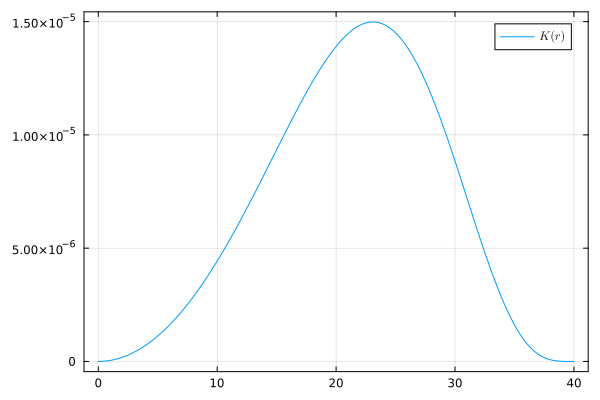

In [115]:
#=============================================================================#
# Setting up LTB model
#=============================================================================#

# LTB functions
K(r) = ifelse(r > r_b, 0.0, -r^2 * k_max * ((r/r_b)^n - 1)^m)
K_r(r) = ifelse(r > r_b, 0.0, -2*r*k_max*((r/r_b)^n - 1)^m - r*k_max*n*m*((r/r_b)^n-1)^(m-1)*(r/r_b)^n)
K_rr(r) = ifelse(r > r_b, 0.0, -2*k_max*((r/r_b)^n - 1)^m - k_max*n*m*(3+n)*((r/r_b)^n - 1)^(m-1)*(r/r_b)^n - k_max*n^2*m*(m-1)*((r/r_b)^n - 1)^(m-2)*(r/r_b)^(2n))

M(r) = 4/3 * pi * G_N * r^3 * a_i^3 * rho_bg / c^2 * (1 + 3/5 * K(r) * c^2 / (a_i*H_i*r)^2)
M_r(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (3*r^2 + 3/5 * c^2/(a_i*H_i)^2 * (K(r) + r*K_r(r)))
M_rr(r) = 4/3 * pi * G_N * a_i^3 * rho_bg / c^2 * (6*r + 3/5 * c^2/(a_i*H_i)^2 * (2*K_r(r) + r*K_rr(r)))

# LCDM background
t_of_a(a) = (2/3) * (1/H_0) / sqrt(Ω_Λ) * asinh(sqrt(Ω_Λ/Ω_m) * a^(3/2))
a(t) = (Ω_m/Ω_Λ)^(1/3) * cbrt(sinh((3/2) * sqrt(Ω_Λ) * H_0 * t))^2
a_t(t) = H_0 * sqrt(Ω_m/a(t) + Ω_Λ * a(t)^2)
H_FLRW(z) = H_0 * sqrt(Ω_m * (1+z)^3 + Ω_Λ)

# Numerical solution of LTB dynamics
t_0 = t_of_a(1.0)
t_i = t_of_a(a_i)
tspan = (t_i, t_0)

# Initial conditions
A_i(r) = a_i * r
A_r_i(r) = a_i
A_rr_i(r) = 0.0
u0 = [A_i.(r_grid); A_r_i.(r_grid); A_rr_i.(r_grid)]

plot(r_grid, K.(r_grid), label=L"K(r)")

In [116]:
# Parameters for ODEs
p = (
    -K.(r_grid) * c^2,               # p[1]
    2*M.(r_grid) * c^2,           # p[2]
    fill(Lambda/3, length(r_grid)),   # p[3]
    2*M_r.(r_grid) * c^2,         # p[4]
    2*M.(r_grid) * c^2,           # p[5]
    -K_r.(r_grid) * c^2,             # p[6]
    fill(2*Lambda/3, length(r_grid)), # p[7]
    -K_rr.(r_grid) * c^2,            # p[8]
    2*M_rr.(r_grid) * c^2,        # p[9]
    -4*M_r.(r_grid) * c^2,        # p[10]
    4*M.(r_grid) * c^2            # p[11]
)

# Defining the system of ODEs for A, A_r, and A_rr
function LTB_eq!(du, u, p, t)
    N = length(u) ÷ 3
    A   = @view u[1:N]
    Ar  = @view u[N+1:2N]
    Arr = @view u[2N+1:end]
    dA   = @view du[1:N]
    dAr  = @view du[N+1:2N]
    dArr = @view du[2N+1:end]

    @. dA = sqrt(p[1] + p[2]/A + p[3]*A^2)
    @. dAr = (p[4]/A - (p[5]*Ar)/(A^2) + p[6] + p[7]*A*Ar) / (2 * dA)
    @. dArr = ((p[8] + p[9]/A + (p[10]*Ar)/(A^2) + (p[11]*Ar^2)/(A^3) - (p[5]*Arr)/(A^2) + p[7]*Ar^2 + p[7]*A*Arr) - 2*dAr^2) / (2 * dA)
end

    
prob_LTB = ODEProblem(LTB_eq!, u0, tspan, p)
sol_LTB = solve(prob_LTB, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

DomainError: DomainError with -3.254051234036674e-30:
sqrt was called with a negative real argument but will only return a complex result if called with a complex argument. Try sqrt(Complex(x)).
DomainError detected in the user `f` function. This occurs when the domain of a function is violated.
For example, `log(-1.0)` is undefined because `log` of a real number is defined to only output real
numbers, but `log` of a negative number is complex valued and therefore Julia throws a DomainError
by default. Cases to be aware of include:

* `log(x)`, `sqrt(x)`, `cbrt(x)`, etc. where `x<0`
* `x^y` for `x<0` floating point `y` (example: `(-1.0)^(1/2) == im`)

Within the context of SciML, this error can occur within the solver process even if the domain constraint
would not be violated in the solution due to adaptivity. For example, an ODE solver or optimization
routine may check a step at `new_u` which violates the domain constraint, and if violated reject the
step and use a smaller `dt`. Howe

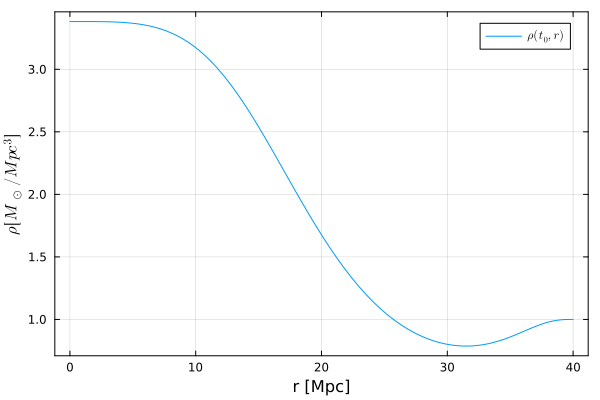

In [117]:
# Interpolate solution for A, A_r, A_rr and their time derivatives
# GEMINI INSERT START
# 1. Local cubic curve math
@inline function local_cubic(y1, y2, y3, y4, w)
    return y2 + 0.5 * w * (y3 - y1 + w * (2.0*y1 - 5.0*y2 + 4.0*y3 - y4 + w * (3.0*(y2 - y3) + y4 - y1)))
end

# 2. Dynamic, extrapolation-safe evaluator
function fast_eval(sol, t, r, offset, t_deriv=false)
    # Use your dynamically defined grid
    r_start = first(r_grid)
    r_end = last(r_grid)
    dr = step(r_grid)
    
    # Helper to grab values from the solver cleanly
    get_val(idx) = t_deriv ? sol(t, Val{1}, idxs=idx+offset) : sol(t, idxs=idx+offset)

    # Find exact position on the grid
    fi = (r - r_start) / dr + 1
    i = clamp(floor(Int, fi), 1, N-1)
    w = fi - i 
    
    # Extract 4 points. If we are right against the edge (i=1 or i=N-1), 
    # we create a "ghost point" to keep the curve perfectly smooth.
    y2 = get_val(i)
    y3 = get_val(i+1)
    y1 = i > 1 ? get_val(i-1) : 2.0*y2 - y3
    y4 = i < N-1 ? get_val(i+2) : 2.0*y3 - y2
    
    return local_cubic(y1, y2, y3, y4, w)
end

A_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0)
A_r_intp = (t,r) -> fast_eval(sol_LTB, t, r, N)
A_rr_intp = (t,r) -> fast_eval(sol_LTB, t, r, 2*N)
A_t_intp = (t,r) -> fast_eval(sol_LTB, t, r, 0, true)
A_tr_intp = (t,r) -> fast_eval(sol_LTB, t, r, N, true)

# GEMINI INSERT END

# Direct definitions - No middle step needed
A(t, r)   = (r > r_b) ? a(t)*r   : A_intp(t, r)
A_r(t, r)  = (r > r_b) ? a(t)     : A_r_intp(t, r)
A_rr(t, r) = (r > r_b) ? 0.0      : A_rr_intp(t, r)
A_t(t, r)  = (r > r_b) ? a_t(t)*r : A_t_intp(t, r)
A_tr(t, r) = (r > r_b) ? a_t(t)   : A_tr_intp(t, r)

# LTB metric
gtt() = -c^2
grr(t, r) = A_r(t, r)^2 / (1 - K(r))
gθθ(t, r) = A(t, r)^2
gϕϕ(t, r, θ) = A(t, r)^2 * sin(θ)^2

# Calculate rho, theta and sigma of LTB
ρ(t, r) = @. (c^2 / (4*pi*G_N)) * (M_r(r) / (A(t,r)^2 * A_r(t,r)))

plot(r_grid, ρ.(t_0, r_grid)/(rho_bg * a_i^3 ./ a.(t_0).^3), label=L"\rho(t_0, r)", xlabel="r [Mpc]", ylabel=L"\rho [M_\odot/Mpc^3]")

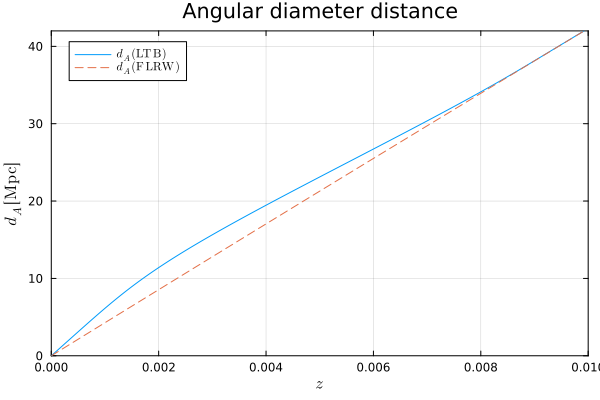

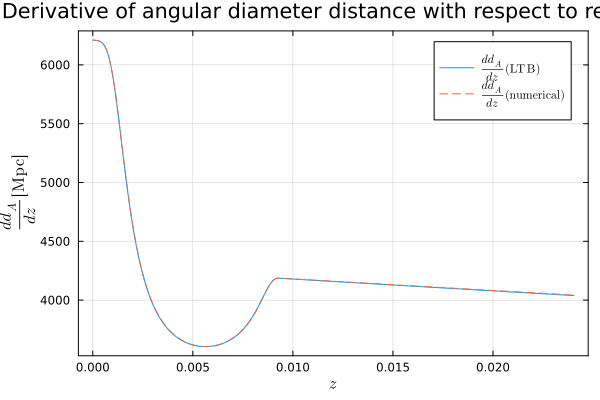

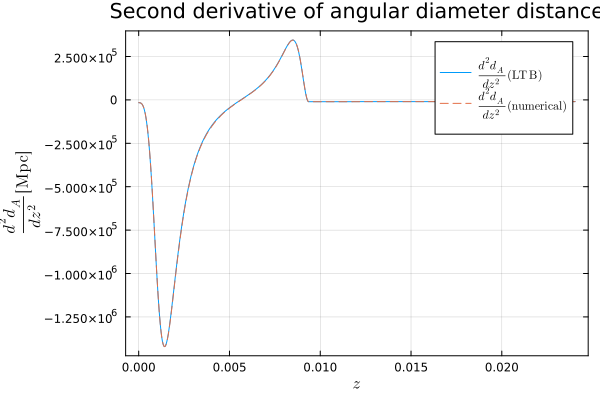

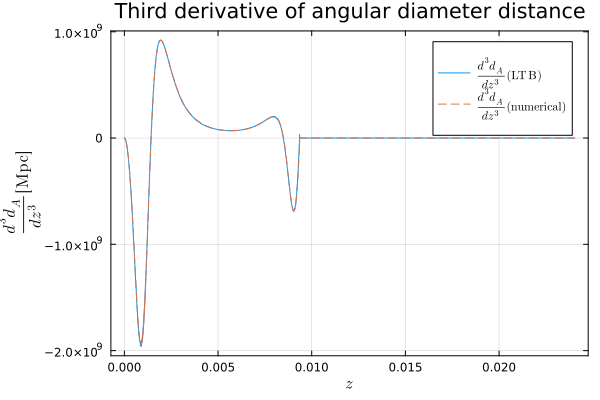

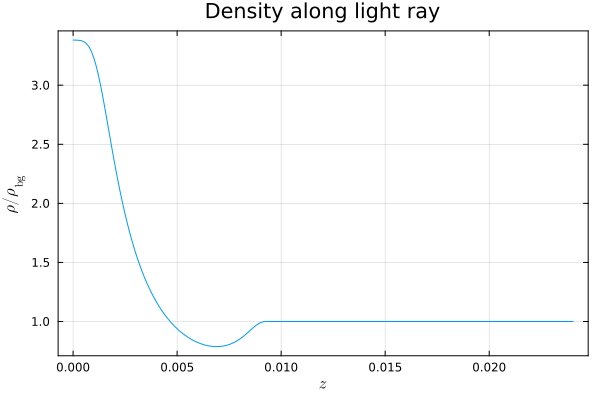

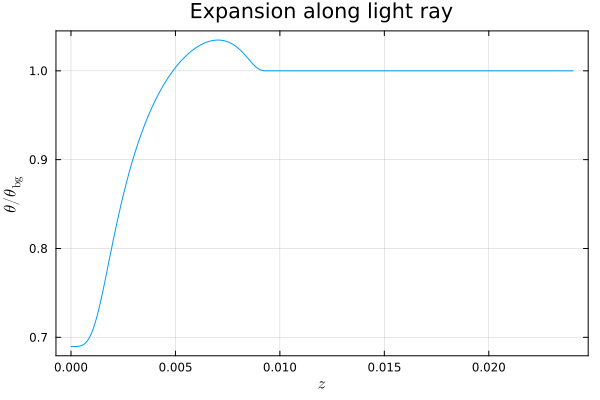

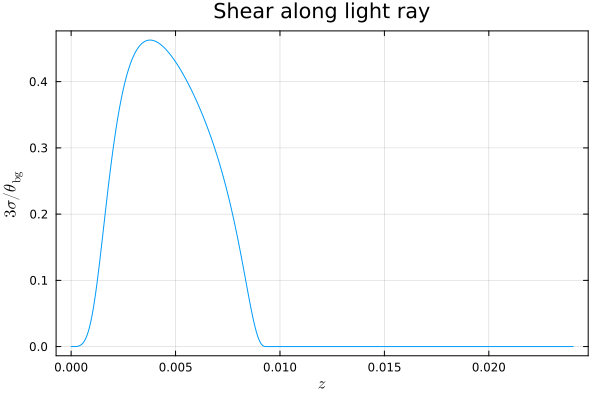

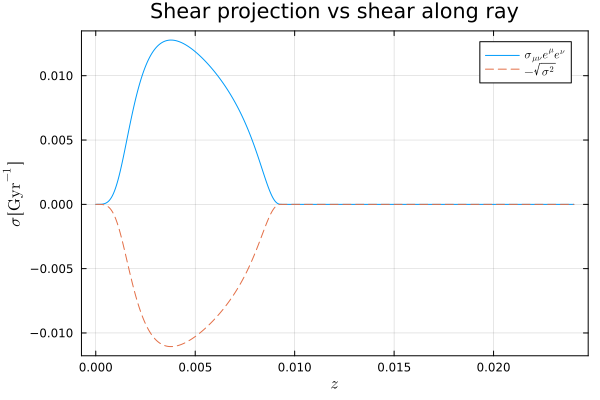

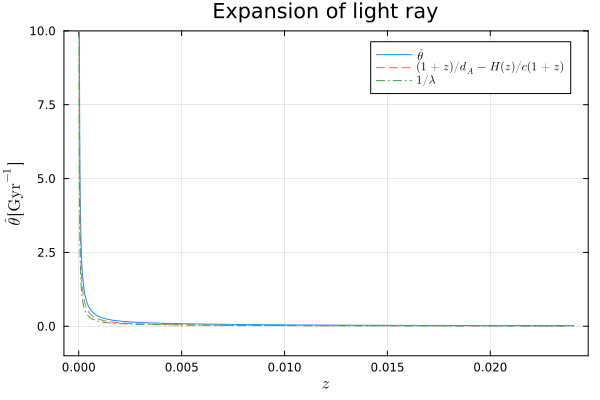

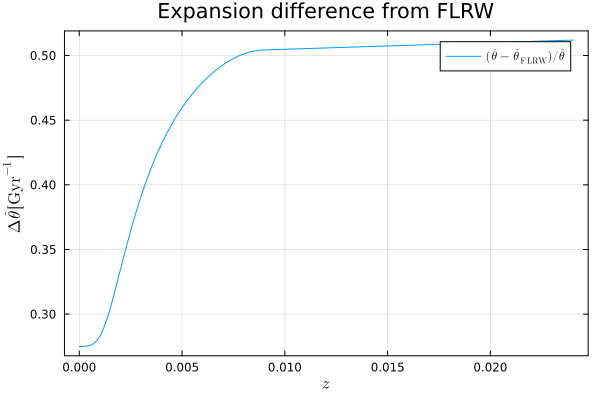

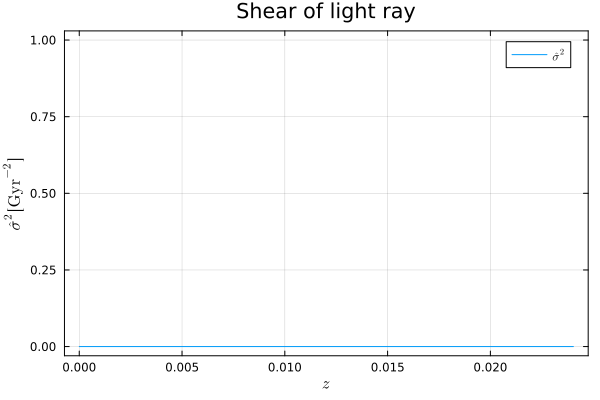

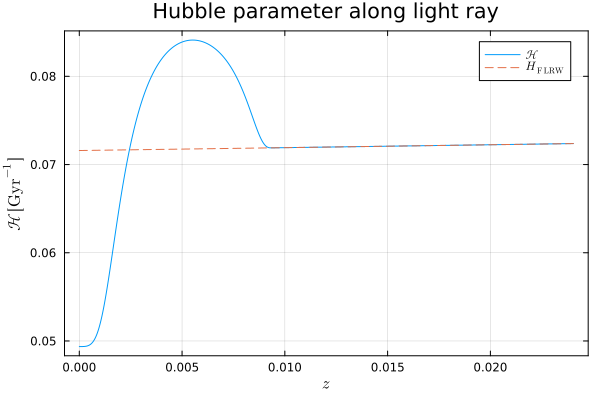

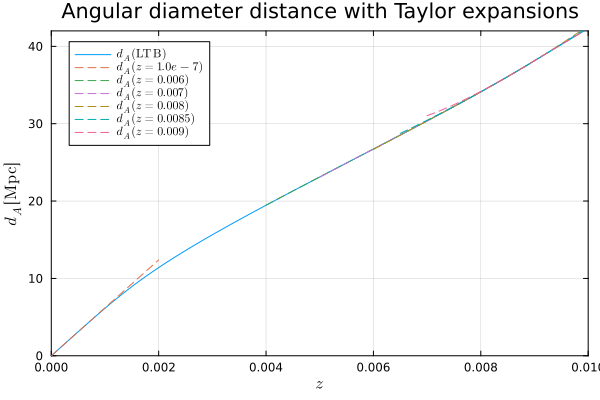

In [118]:
θ(t, r) = @. (A_tr(t,r)/A_r(t,r) + 2*A_t(t,r)/A(t,r))
σ²(t, r) = @. (1/3) * (A_tr(t,r)/A_r(t,r) - A_t(t,r)/A(t,r))^2
R(t,r, kt) = (8*pi*G_N/c^4) * ρ(t,r) * kt^2 * c^4 # R = R_\mu\nu k^\mu k^\nu

#=============================================================================#
# Ray tracing
#=============================================================================#

# Geodesic ray tracing
function geodesic_eq!(du, u, p, λ)
    @views x = u[1:4]   # Position: [t, r, θ, φ]
    @views k = u[5:8]   # Momentum: [k_t, k_r, k_θ, k_φ]
    @views D = u[9:12]  # Deviation vector
    @views D_λ = u[13:16] # Deviation velocity
    
    #if x[2] < 0.001 && k[2] < 0
    #    println("Warning: Light ray is at r=0 with negative radial momentum. Reflecting to avoid numerical issues.")
    #    k[2] = -k[2] # Reflect at r=0 to avoid numerical issues
    #end

    A_i = A(x[1], x[2])
    A_r_i = A_r(x[1], x[2])
    A_rr_i = A_rr(x[1], x[2])
    A_t_i = A_t(x[1], x[2])
    A_tr_i = A_tr(x[1], x[2])

    # Geodesic equation: dx/dλ = k
    du[1:4] .= k

    # dk/dλ = -Γ^μ_{αβ} k^α k^β
    du[5] = -(A_tr_i*A_r_i)/(c^2*(1-K(x[2]))) * k[2]^2 - (A_i*A_t_i)/c^2 * k[3]^2 - (A_i*A_t_i*sin(x[3])^2)/c^2 * k[4]^2
    du[6] = -2*(A_tr_i/A_r_i) * k[1]*k[2] - (A_rr_i/A_r_i + K_r(x[2])/(2-2*K(x[2]))) * k[2]^2 + (A_i/A_r_i)*(1-K(x[2])) * k[3]^2 + (A_i/A_r_i)*(1-K(x[2]))*sin(x[3])^2 * k[4]^2
    du[7] = -2*(A_t_i/A_i) * k[1]*k[3] - 2*(A_r_i/A_i) * k[2]*k[3] + cos(x[3])*sin(x[3]) * k[4]^2
    du[8] = -2*(A_t_i/A_i) * k[1]*k[4] - 2*(A_r_i/A_i) * k[2]*k[4] - 2*(cos(x[3])/sin(x[3])) * k[3]*k[4]

    du[9:12] .= D_λ
    du[13:16] .= -R(x[1], x[2], k[1])/2 .* D
end

# Initial conditions of light ray
x0 = [t_0, xr0, xθ0, xϕ0]

p_hat_r = sin(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) + cos(xθ0) * cos(theta_hp)
p_hat_θ = cos(xθ0) * sin(theta_hp) * cos(xϕ0 - phi_hp) - sin(xθ0) * cos(theta_hp)
p_hat_ϕ = sin(theta_hp) * sin(phi_hp - xϕ0)

energy_factor = kt0 * sqrt(-gtt())

kr0 = kt0 * p_hat_r * sqrt(-gtt() / grr(x0[1], x0[2]))
kθ0 = kt0 * p_hat_θ * sqrt(-gtt() / gθθ(x0[1], x0[2]))
kϕ0 = kt0 * p_hat_ϕ * sqrt(-gtt() / gϕϕ(x0[1], x0[2], x0[3]))

k0 = [kt0, kr0, kθ0, kϕ0]

k0[abs.(k0) .< 1e-15] .= 0.0 # Avoid tiny nonzero values that can cause numerical issues

D0 = [0.0, 0.0, 0.0, 0.0] # Flattening matrix D_0
D_λ0 = [1.0, 0.0, 0.0, 1.0] # Flattening matrix V_0

u0 = vcat(x0, k0, D0, D_λ0)

# Raytracing from lambda=0 to lambda=100
lspan = (0, 100)

# Tighter threshold so near-miss rays curve naturally without triggering
condition_r0(u, λ, integrator) = u[2] - 1e-15

function affect_r0!(integrator)
    # Coordinate teleportation
    integrator.u[3] = π - integrator.u[3]   # θ → π - θ
    integrator.u[4] = integrator.u[4] + π   # φ → φ + π
    
    # Momentum adjustment (Preserving the straight-line velocity)
    integrator.u[6] = -integrator.u[6]      # k_r → -k_r  (now moving outward)
    # k_θ remains unchanged! Do NOT flip u[7]
    integrator.u[8] = -integrator.u[8]      # k_φ → -k_φ
end

# Correct argument order: affect_r0! for inward falling (+ to -), nothing for outward (- to +)
cb_r0 = ContinuousCallback(condition_r0, nothing, affect_r0!)

prob_geo = ODEProblem(geodesic_eq!, u0, lspan, callback=cb_r0)
sol_geo = solve(prob_geo, Tsit5(), reltol=1e-12, abstol=1e-12, dense=true)

# Collecting solutions
xt(λ) = sol_geo(λ)[1]
xr(λ) = sol_geo(λ)[2]
xθ(λ) = sol_geo(λ)[3]
xϕ(λ) = sol_geo(λ)[4]

kt(λ) = sol_geo(λ)[5]
kr(λ) = sol_geo(λ)[6]
kθ(λ) = sol_geo(λ)[7]
kϕ(λ) = sol_geo(λ)[8]

D(λ) = reshape(sol_geo(λ)[9:12], 2, 2)
D_λ(λ) = reshape(sol_geo(λ)[13:16], 2, 2)

#=============================================================================#
# Cosmography calculations
#=============================================================================#

z(λ) = kt(λ) / kt(0) - 1

dA(λ) = sqrt(D(λ)[1, 1]*D(λ)[2, 2] - D(λ)[1, 2]*D(λ)[2, 1])

r_comoving_FLRW(z) = first(quadgk(z_ -> 1/H_FLRW(z_), 0, z))
dA_FLRW(λ) = r_comoving_FLRW(z(λ)) * c

S(λ) = D_λ(λ) * inv(D(λ))

θ̂(λ) = (S(λ)[1, 1] .+ S(λ)[2, 2])

σ̂²(λ) = (S(λ)[1, 1]^2 + S(λ)[2, 2]^2 + S(λ)[1, 2]^2 + S(λ)[2, 1]^2 - 2 * S(λ)[1, 1] * S(λ)[2, 2] + 2 * S(λ)[1, 2] * S(λ)[2, 1])/8


σrr(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* 2/3*grr(t,r)
σθθ(t,r) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gθθ(t,r))
σϕϕ(t,r,θ) = (A_tr(t,r)./A_r(t,r) .- A_t(t,r)./A(t,r)) .* (-1/3*gϕϕ(t,r,θ))


σ_proj(λ) = ((kr(λ) / (c * kt(λ)))^2 * σrr(xt(λ), xr(λ)) 
    + (kθ(λ) / (c * kt(λ)))^2 * σθθ(xt(λ), xr(λ))
    + (kϕ(λ) / (c * kt(λ)))^2 * σϕϕ(xt(λ), xr(λ), xθ(λ)))

H(λ) = θ(xt(λ), xr(λ))/3 + σ_proj(λ)

#=============================================================================#
# Derivatives of angular diameter distance
#=============================================================================#

dA_z(λ) = -θ̂(λ)/(2*(1 + z(λ))^2*Ec*H(λ))*dA(λ)

Rkk(λ) = R(xt(λ), xr(λ), kt(λ))

H_λ(λ) = ForwardDiff.derivative(H, λ)
H_λλ(λ) = ForwardDiff.derivative(H_λ, λ)
Rkk_λ(λ) = ForwardDiff.derivative(Rkk, λ)


dA_zz(λ) = (dA(λ) / (2*(1+z(λ))^4 * Ec^2 * H(λ)^2)) * (
    2*θ̂(λ)*Ec*H(λ)*(1+z(λ)) - 2*σ̂²(λ) - Rkk(λ) - (θ̂(λ)/H(λ))*H_λ(λ)
)

dA_zzz(λ) = (dA(λ) / (2*(1+z(λ))^6 * Ec^3 * H(λ)^3)) * (
    θ̂(λ)*Rkk(λ)/2 
    - 2*0 # Setting Weyl term to zero
    - 3*θ̂(λ)*σ̂²(λ) 
    + 12*Ec*H(λ)*σ̂²(λ)*(1+z(λ))
    + 6*Ec*H(λ)*Rkk(λ)*(1+z(λ))
    + 6*Ec*θ̂(λ)*(1+z(λ))*H_λ(λ)
    - 6*Ec^2*H(λ)^2*θ̂(λ)*(1+z(λ))^2
    - 6*σ̂²(λ)/H(λ)*H_λ(λ)
    - 3*Rkk(λ)/H(λ)*H_λ(λ)
    - 3*θ̂(λ)/H(λ)^2*H_λ(λ)^2
    + θ̂(λ)/H(λ)*H_λλ(λ)
    + Rkk_λ(λ)
)


z_vals = z.(sol_geo.t)
λ_of_z = linear_interpolation(z_vals, sol_geo.t, extrapolation_bc=Line())

function dA_exp(z_0)
    λ_0 = λ_of_z(z_0)
    c0_z0 = dA(λ_0)
    c1_z0 = dA_z(λ_0)
    c2_z0 = 0.5 * dA_zz(λ_0)
    c3_z0 = (1/6) * dA_zzz(λ_0)

    dA_z0(z_val) = c0_z0 + c1_z0*(z_val - z_0) + c2_z0*(z_val - z_0)^2 + c3_z0*(z_val - z_0)^3
    return dA_z0
end

#=============================================================================#
# Plotting
#=============================================================================#
λ_ = sol_geo.t[sol_geo.t .> 0.01]
z_eval = z.(λ_)

pdA = plot(z_eval, dA.(λ_), 
    xlabel=L"z", 
    ylabel=L"d_A \, [\mathrm{Mpc}]",
    title="Angular diameter distance", 
    grid=true, 
    label=L"d_A \, \mathrm{(LTB)}", 
    legend=:topleft)
plot!(z_eval, dA_FLRW.(λ_) ./ (1 .+ z_eval), label=L"d_A \, \mathrm{(FLRW)}", linestyle=:dash)
xlims!(0, 0.01)
ylims!(0, 42)
display(pdA)


pdA_z = plot(z_eval, dA_z.(λ_), 
    xlabel=L"z", 
    ylabel=L"\frac{d d_A}{dz} \, [\mathrm{Mpc}]",
    title="Derivative of angular diameter distance with respect to redshift", 
    label=L"\frac{d d_A}{dz} \, \mathrm{(LTB)}")
plot!(z.(λ_[2:end]), diff(dA.(λ_)) ./ diff(z_eval), label=L"\frac{d d_A}{dz} \, \mathrm{(numerical)}", linestyle=:dash)
display(pdA_z)

pdA_zz = plot(z_eval, dA_zz.(λ_), 
    xlabel=L"z", 
    ylabel=L"\frac{d^2 d_A}{dz^2} \, [\mathrm{Mpc}]",
    title="Second derivative of angular diameter distance", 
    label=L"\frac{d^2 d_A}{dz^2} \, \mathrm{(LTB)}")
plot!(z.(λ_[3:end]), diff(dA_z.(λ_[2:end])) ./ diff(z.(λ_[2:end])), label=L"\frac{d^2 d_A}{dz^2} \, \mathrm{(numerical)}", linestyle=:dash)
display(pdA_zz)

pdA_zzz = plot(z_eval, dA_zzz.(λ_), 
    xlabel=L"z", 
    ylabel=L"\frac{d^3 d_A}{dz^3} \, [\mathrm{Mpc}]",
    title="Third derivative of angular diameter distance", 
    label=L"\frac{d^3 d_A}{dz^3} \, \mathrm{(LTB)}")
plot!(z.(λ_[3:end]), diff(dA_zz.(λ_[2:end])) ./ diff(z.(λ_[2:end])), label=L"\frac{d^3 d_A}{dz^3} \, \mathrm{(numerical)}", linestyle=:dash)
display(pdA_zzz)

# Density along light ray
prho = plot(z_eval, ρ(xt.(λ_), xr.(λ_)) ./ (rho_bg * a_i^3 ./ a.(xt.(λ_)).^3),
    xlabel=L"z", ylabel=L"\rho/\rho_\mathrm{bg}",
    title="Density along light ray")
display(prho)

# Expansion along light ray
ptheta = plot(z_eval, θ(xt.(λ_), xr.(λ_)) ./ 3H_FLRW.(z_eval),
    xlabel=L"z", ylabel=L"\theta/\theta_\mathrm{bg}",
    title="Expansion along light ray")
display(ptheta)

# Shear along light ray
psigma = plot(z_eval, 3sqrt.(σ²(xt.(λ_), xr.(λ_))) ./ H_FLRW.(z_eval),
    xlabel=L"z", ylabel=L"3\sigma/\theta_\mathrm{bg}",
    title="Shear along light ray")
display(psigma)

# Shear projection along light ray
psigmaproj = plot(z_eval, σ_proj.(λ_), 
    label=L"\sigma_{\mu\nu} e^\mu e^\nu",
    xlabel=L"z", 
    ylabel=L"\sigma \, [\mathrm{Gyr}^{-1}]",
    title="Shear projection vs shear along ray")
plot!(z_eval, -sqrt.(σ²(xt.(λ_), xr.(λ_))), label=L"-\sqrt{\sigma^2}", linestyle=:dash)
display(psigmaproj)

# Expansion of light ray
pexpan = plot(z_eval, θ̂.(λ_), 
    label=L"\hat{\theta}",
    xlabel=L"z", 
    ylabel=L"\hat{\theta} \, [\mathrm{Gyr}^{-1}]",
    title="Expansion of light ray")  
plot!(z_eval, (1 .+ z_eval) ./ dA_FLRW.(λ_) - H_FLRW.(z_eval)/c .* (1 .+ z_eval),
    label=L"(1 + z)/d_A - H(z)/c (1+z)", linestyle=:dash)
plot!(z_eval, 1 ./ λ_, label=L"1/\lambda", linestyle=:dashdot)
ylims!(-1, 10)
display(pexpan)

# Expansion difference
pexpandiff = plot(z_eval, (θ̂.(λ_) .- ((1 .+ z_eval) ./ dA_FLRW.(λ_) - H_FLRW.(z_eval)/c .* (1 .+ z_eval)))./θ̂.(λ_),
    xlabel=L"z", 
    ylabel=L"\Delta\hat{\theta} \, [\mathrm{Gyr}^{-1}]",
    title="Expansion difference from FLRW",
    label=L"(\hat{\theta} - \hat{\theta}_\mathrm{FLRW})/\hat{\theta}")
display(pexpandiff)

# Shear of light ray
pshear = plot(z_eval, σ̂².(λ_), 
    xlabel=L"z", 
    ylabel=L"\hat{\sigma}^2 \, [\mathrm{Gyr}^{-2}]",
    title="Shear of light ray", 
    label=L"\hat{\sigma}^2")
display(pshear)

pH = plot(z_eval, H.(λ_), 
    xlabel=L"z", 
    ylabel=L"\mathcal{H} \, [\mathrm{Gyr}^{-1}]",
    title="Hubble parameter along light ray", 
    label=L"\mathcal{H}")
plot!(z_eval, H_FLRW.(z_eval), label=L"H_\mathrm{FLRW}", linestyle=:dash)
display(pH)

z0 = 1e-7
z1 = 0.006
z2 = 0.007
z3 = 0.008
z4 = 0.0085
z5 = 0.009

function z_range(z0, Δz=0.002)
    z_min = z0 - Δz
    z_max = z0 + Δz
    return λ_of_z(z_min:0.00001:z_max)
end

pTaylor = plot(z_eval, dA.(λ_), label=L"d_A \, \mathrm{(LTB)}", legend=:topleft,
    xlabel=L"z", ylabel=L"d_A \, [\mathrm{Mpc}]", title="Angular diameter distance with Taylor expansions", legendfonthalign = :left)
plot!(z.(z_range(z0)), dA_exp(z0).(z.(z_range(z0))), label=latexstring("d_A \\, (z=$(z0))"), linestyle=:dash)
plot!(z.(z_range(z1)), dA_exp(z1).(z.(z_range(z1))), label=latexstring("d_A \\, (z=$(z1))"), linestyle=:dash)
plot!(z.(z_range(z2)), dA_exp(z2).(z.(z_range(z2))), label=latexstring("d_A \\, (z=$(z2))"), linestyle=:dash)
plot!(z.(z_range(z3)), dA_exp(z3).(z.(z_range(z3))), label=latexstring("d_A \\, (z=$(z3))"), linestyle=:dash)
plot!(z.(z_range(z4)), dA_exp(z4).(z.(z_range(z4))), label=latexstring("d_A \\, (z=$(z4))"), linestyle=:dash)
plot!(z.(z_range(z5)), dA_exp(z5).(z.(z_range(z5))), label=latexstring("d_A \\, (z=$(z5))"), linestyle=:dash)
#xlims!(0.004, 0.010)
#ylims!(14, 42)
xlims!(0, 0.01)
ylims!(0, 42)
display(pTaylor)